In [1]:
import os
import numpy as np
import pandas as pd
import pickle
from pandas import HDFStore

In [2]:
ASSETS = {'KGHM': [10783], 'PKNORLEN': [11319], 'PKOBP': [11314], 'PZU': [10735], 'PEKAO': [11322]}
data_path = r'../msg_data/orders/' 

### Available keys in hdf5 files
Example for KGHM but for all files keys are the same

In [3]:
asset = 'KGHM'
with HDFStore(os.path.join(data_path, f'{asset}_lob_2017_zlib.h5'), mode='r') as hdf:
    keys = hdf.keys()
keys

['/d20170102',
 '/d20170103',
 '/d20170104',
 '/d20170105',
 '/d20170109',
 '/d20170110',
 '/d20170111',
 '/d20170112',
 '/d20170113',
 '/d20170116',
 '/d20170117',
 '/d20170118',
 '/d20170119',
 '/d20170120',
 '/d20170123',
 '/d20170124',
 '/d20170125',
 '/d20170126',
 '/d20170127',
 '/d20170130',
 '/d20170131',
 '/d20170201',
 '/d20170202',
 '/d20170203',
 '/d20170206',
 '/d20170207',
 '/d20170208',
 '/d20170209',
 '/d20170210',
 '/d20170213',
 '/d20170214',
 '/d20170215',
 '/d20170216',
 '/d20170217',
 '/d20170220',
 '/d20170221',
 '/d20170222',
 '/d20170223',
 '/d20170224',
 '/d20170227',
 '/d20170228',
 '/d20170301',
 '/d20170302',
 '/d20170303',
 '/d20170306',
 '/d20170307',
 '/d20170308',
 '/d20170309',
 '/d20170310',
 '/d20170313',
 '/d20170314',
 '/d20170315',
 '/d20170316',
 '/d20170317',
 '/d20170320',
 '/d20170321',
 '/d20170322',
 '/d20170323',
 '/d20170324',
 '/d20170327',
 '/d20170328',
 '/d20170329',
 '/d20170330',
 '/d20170331',
 '/d20170403',
 '/d20170404',
 '/d201704

### Example of DataFrame

In [4]:
asset = 'KGHM'
key = '/d20170110'
df = pd.read_hdf(os.path.join(data_path, f'{asset}_lob_2017_zlib.h5'), key)
df.head()

,time,priority_date,order_date,symbol_idx,price,agg_volume,volume,order_id,num_orders,side,order_type,action_type,price_level
727785,1484020894357292000,-1,-1,10783,0,0,0,0,0,-1,-1,F,2
727786,1484020897211952000,1483388200734153000,1483315200000000000,10783,10075,45,45,3,1,2,2,Y,2
727787,1484020897212585000,1483388203646205000,1483315200000000000,10783,10245,12,12,13,1,2,2,Y,2
727788,1484020897213705000,1483388205639040000,1483315200000000000,10783,10000,300,300,16,1,2,2,Y,2
727789,1484020897213717000,1483388205640815000,1483315200000000000,10783,12000,300,300,17,1,2,2,Y,2


### Description of columns
Columns `symbol_idx`+`order_date`+`order_id` uniquely identify transactions.

- `time` - int - Time of sending the message in the system, timestamps
- `priority_date` - int - Time giving the priority of the order, timestamps, (-1 if not provided)
- `order_date` - int - Date of order (To be combined with `order_id`), timestamps, (-1 if not provided)
- `symbol_idx` - int - UTP-MD proprietary identification of the instrument
- `price` - int - Price in the order (To be calculated with the `price_level`)
- `agg_volume` - int - Total quantity of orders at the given price level
- `volume` - int - Displayed quantity of the order.
- `order_id` - int - Identifies the uniqueness of the order, when combined with `order_date`
- `num_orders` - int - Number of orders in the Book at the price of the current order
- `side` - int - Indicates the side of the order. Valid values:
   - `1` - buy, 
   - `2` - sell, 
   - `5` - sell short,
   - `-1` - not provided
- `order_type` - str - Type of Order. Valid values:
   - `1` - Market order
   - `2` - Limit order
   - `K` - Market to limit order
   - `P` - Peg order
   - `-1` - Not provided
- `action_type` - str - This field identifies the type of operation on order book. Valid values:
   - `A` - New order
   - `M` - Modification of existing order (case of partial fill)
   - `D` - Deletion of order identified by `order_id`
   - `F` - Deletion all orders for one instrument at the start of the day before the order book retransmission
   - `Y` - Retransmission of all orders forthe given instrument
- `price_level` - int - Divide factor to combine with `price` in order to convert to float, (`price/(10^price_level)`)

### Conversion of  timestamps to datetime and scaling of price

In [5]:
df['time'] = (pd.to_datetime(df['time'], unit='ns', utc=True)).dt.tz_convert('Europe/Warsaw')
df['priority_date'] = (pd.to_datetime(df['priority_date'], unit='ns', utc=True)).dt.tz_convert('Europe/Warsaw')
df['order_date'] = (pd.to_datetime(df['order_date'], unit='ns', utc=True)).dt.tz_convert('Europe/Warsaw')
df['price'] = df['price'] / (10**df['price_level'])
df.head()

,time,priority_date,order_date,symbol_idx,price,agg_volume,volume,order_id,num_orders,side,order_type,action_type,price_level
727785,2017-01-10 05:01:34.357292+01:00,1970-01-01 00:59:59.999999999+01:00,1970-01-01 00:59:59.999999999+01:00,10783,0.00,0,0,0,0,-1,-1,F,2
727786,2017-01-10 05:01:37.211952+01:00,2017-01-02 21:16:40.734153+01:00,2017-01-02 01:00:00+01:00,10783,100.75,45,45,3,1,2,2,Y,2
727787,2017-01-10 05:01:37.212585+01:00,2017-01-02 21:16:43.646205+01:00,2017-01-02 01:00:00+01:00,10783,102.45,12,12,13,1,2,2,Y,2
727788,2017-01-10 05:01:37.213705+01:00,2017-01-02 21:16:45.639040+01:00,2017-01-02 01:00:00+01:00,10783,100.00,300,300,16,1,2,2,Y,2
727789,2017-01-10 05:01:37.213717+01:00,2017-01-02 21:16:45.640815+01:00,2017-01-02 01:00:00+01:00,10783,120.00,300,300,17,1,2,2,Y,2


### Example of generating a snapshot of the order book after 10 000 events with our OrderBook class

In [6]:
from orderbook2 import OrderBook
from copy import deepcopy

In [7]:
df = df.set_index('time')

In [10]:
ob = OrderBook()
for i, row in df.iterrows():
    stamp = i
    ob.current_time = deepcopy(stamp)
    ob.nmsg += 1

    if row.action_type == 'F':
        ob.clear_orderbook()
    elif row.action_type == 'Y':
        ob.retransmit_order(row)
    elif row.action_type == 'A':
        ob.add_order(row)
    elif row.action_type == 'M':
        ob.mod_order(row)
    elif row.action_type == 'D':
        ob.del_order(row)
    else:
        raise ValueError('unsupported action_type')
    if ob.nmsg >= 10000:
        break

In [12]:
ob.summary()

Current time is 2017-01-10 09:13:49.142262+01:00

Ask price levels:   510
Bid price levels:   299
Total price levels: 809

Ask orders:         1529
Bid orders:         525
Total orders:       2054

Ask volume:         339810
Bid volume:         102734
Total volume:       442544 

Spread:             0.16
Mid point:          97.71
WAP:                97.70

Best Ask:           97.79
Volume:             360

Best Bid:           97.63
Volume:             259
        


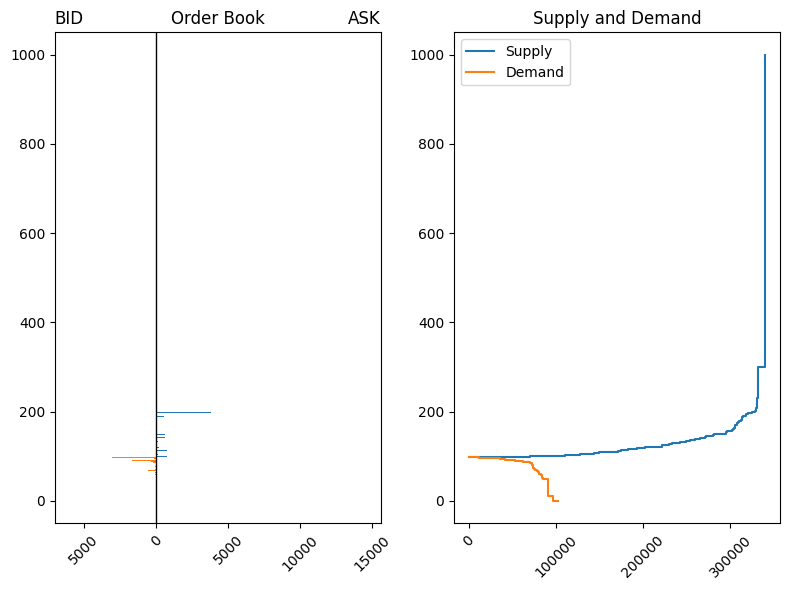

In [15]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(8,6))
ob.plot(ax=ax1)
ob.plot_sd(ax=ax2)
plt.tight_layout()
plt.show()